# Definición del Problema de Negocio

## Contexto del Negocio

El mercado de **tarjetas de crédito** es altamente competitivo. Actualmente, el banco cuenta con un portafolio de aproximadamente **10.000 clientes** de tarjetas de crédito.

Históricamente, el **costo de adquisición de un cliente nuevo (CAC)** puede ser hasta **5 veces mayor** que el costo de implementar estrategias orientadas a retener a un cliente actual.

---

## El Problema

Se ha identificado una tasa de abandono (*Churn*) del **16%**, equivalente aproximadamente a **1.627 clientes**.

Esta fuga constante de clientes impacta directamente en los ingresos del banco, principalmente por:

- Cuotas de manejo.
- Comisiones por transacción.
- Disminución de la actividad financiera de los clientes.
- Mayor inversión en estrategias de marketing para adquirir nuevos clientes.

En consecuencia, el banco debe realizar esfuerzos adicionales de adquisición para compensar la pérdida constante de clientes actuales.


## Objetivos y Métricas de Éxito

### Objetivo Principal

Desarrollar una **solución analítica predictiva** que permita identificar de manera anticipada a los clientes con alta probabilidad de cancelar su tarjeta de crédito, facilitando al área comercial la ejecución de **campañas de retención proactivas**.

---

### Métricas de Éxito del Negocio

#### Reducción de la Tasa de Abandono

Reducir la tasa de abandono mensual (*Churn*) en un **15% durante el primer trimestre de implementación**.

#### Retorno de la Inversión (ROI) de la Campaña

Evaluar la rentabilidad de las campañas de retención mediante el ahorro neto generado:

**Ahorro neto generado = (Clientes en riesgo retenidos × CAC ahorrado) − Inversión en incentivos de retención**

Esta métrica permite comparar el valor económico generado por la retención de clientes frente al costo de los incentivos utilizados en las campañas.

---

### Métricas de Éxito del Modelo

#### Recall (Sensibilidad)

El **Recall** será la principal métrica técnica del modelo, debido a que el objetivo prioritario es identificar la mayor cantidad posible de clientes que realmente presentan riesgo de abandono.

En este contexto, se considera preferible asumir **falsos positivos**, es decir, ofrecer una estrategia de retención a un cliente que finalmente no iba a abandonar, antes que generar **falsos negativos**, que corresponden a clientes que sí abandonan pero no son identificados por el modelo.

Por lo tanto, el modelo debe priorizar la **detección de clientes en riesgo de abandono**, buscando minimizar la cantidad de falsos negativos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Librerías para imputación, escalado y encoding
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Configuración visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import missingno as msno

# Carga de datos
df = pd.read_csv('https://raw.githubusercontent.com/JulianRuano/Data-Analysis/main/BankChurners.csv')

In [3]:
df.shape

(10127, 21)

In [4]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


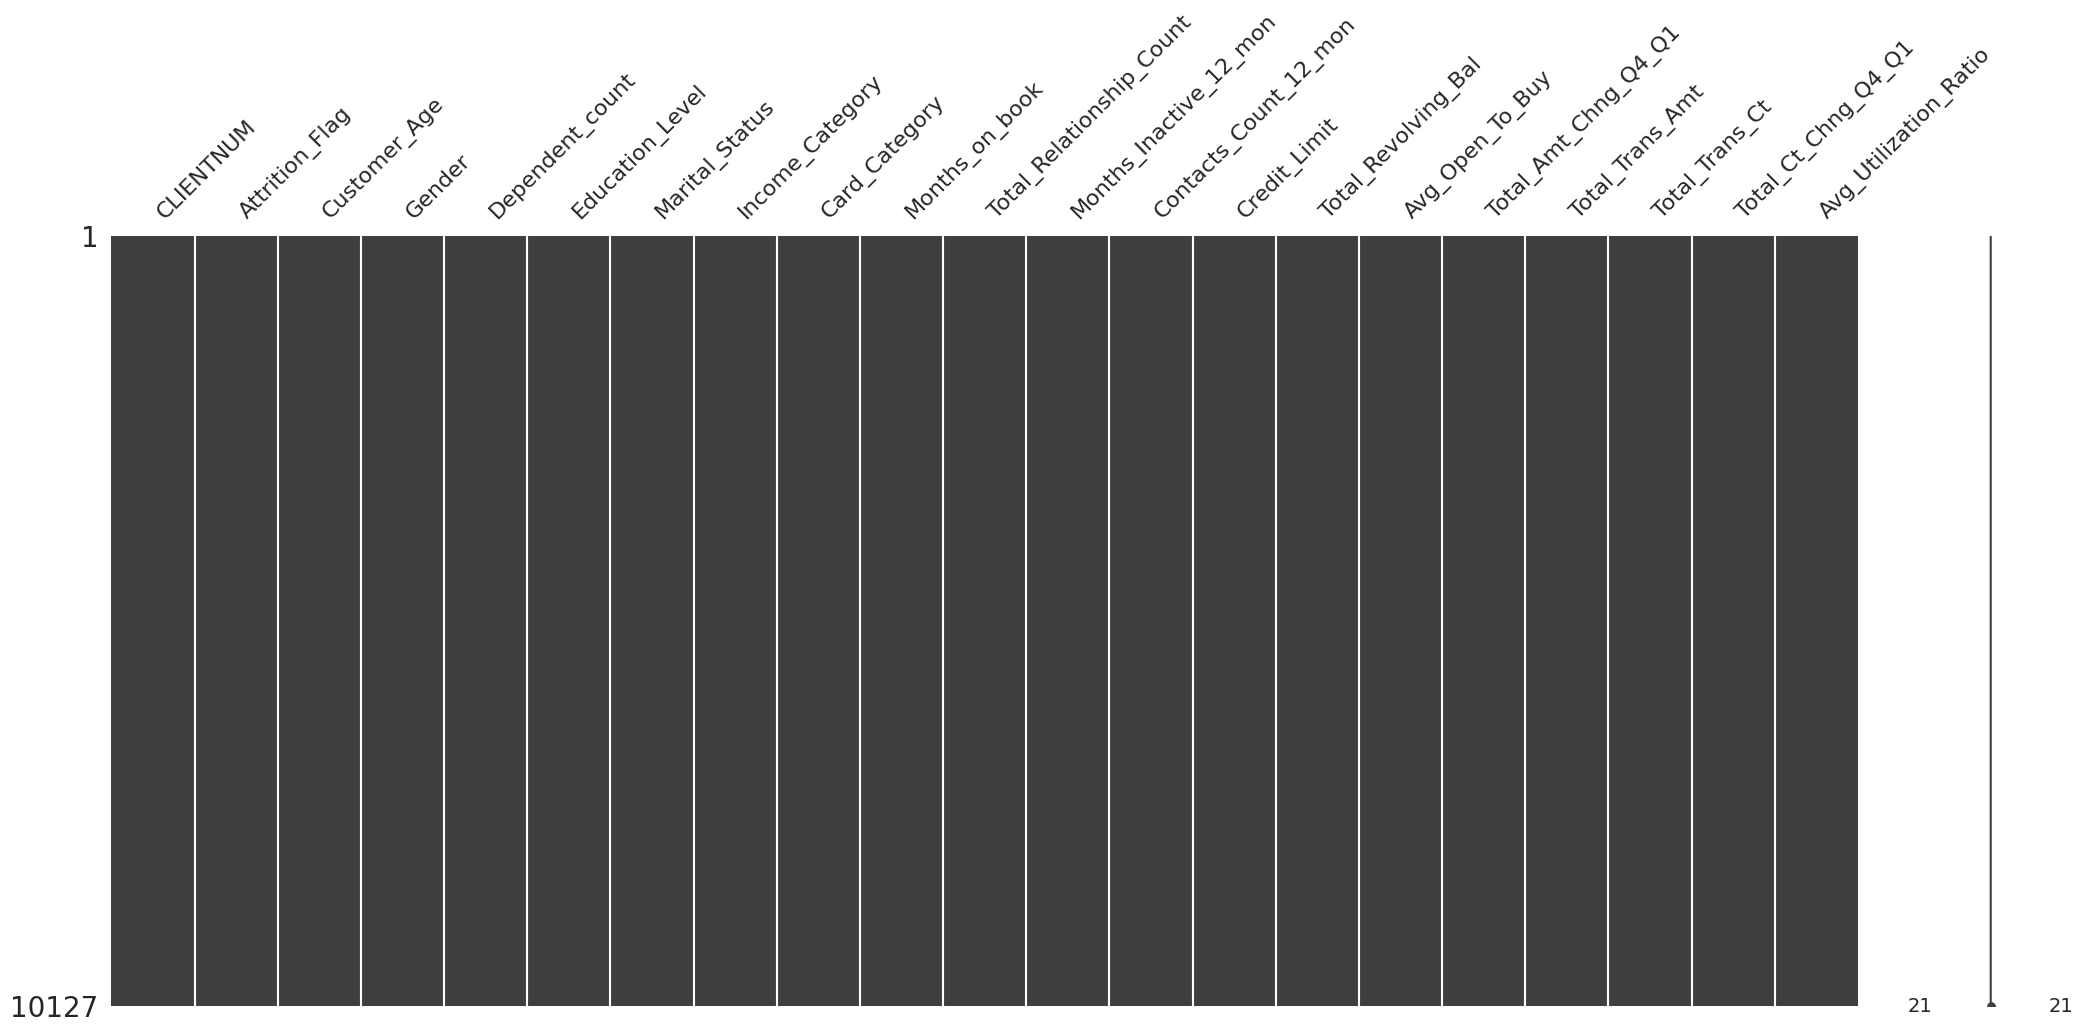

In [ ]:
# Gráfico de matriz: Muestra un mapa de dónde están los nulos en el dataset
msno.matrix(df)
plt.show()

In [ ]:
# resume el número de registros no nulos y el tipo de dato de cada columna.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

## Diccionario de Datos

| Variable | Tipo de Dato | Descripción | Relevancia / Rol Esperado |
| :--- | :---: | :--- | :--- |
| **CLIENTNUM** | Numérico | Identificador único de cada cliente. | Excluida del modelo (sin poder predictivo). |
| **Attrition_Flag** | Categórica (Nominal) | Indica si el cliente sigue activo (*Existing Customer*) o canceló su tarjeta (*Attrited Customer*). | **Variable Objetivo (Target).** |
| **Customer_Age** | Numérico (Discreto) | Edad del cliente en años. | Predictora demográfica. |
| **Gender** | Categórica (Nominal) | Género biológico del cliente (M / F). | Predictora demográfica. |
| **Education_Level** | Categórica (Ordinal) | Nivel educativo (ej. *High School, Graduate, Doctorate*). | Predictora socioeconómica. Requiere *Label Encoding*. |
| **Marital_Status** | Categórica (Nominal) | Estado civil del cliente (ej. *Single, Married, Divorced*). | Predictora demográfica. Requiere *One-Hot Encoding*. |
| **Income_Category** | Categórica (Ordinal) | Rango de ingresos anuales del cliente (ej. *< $40K, $80K-$120K*). | Predictora de capacidad de pago. Requiere *Label Encoding*. |
| **Card_Category** | Categórica (Ordinal) | Nivel del producto asignado (*Blue, Silver, Gold, Platinum*). | Indicador de fidelidad/segmento del banco. |
| **Credit_Limit** | Numérico (Continuo) | Límite máximo de crédito asignado a la tarjeta. | Indicador financiero (proxy de riesgo). |
| **Total_Trans_Amt** | Numérico (Continuo) | Suma total de dinero transado en los últimos 12 meses. | **Alta relevancia.** Refleja el volumen de facturación. |
| **Total_Trans_Ct** | Numérico (Discreto) | Cantidad de operaciones (compras) realizadas en el último año. | **Alta relevancia.** Refleja la frecuencia y transaccionalidad. |
| **Avg_Utilization_Ratio**| Numérico (Continuo) | Proporción de uso del límite de crédito (Saldo consumido / Límite total). | **Alta relevancia.** Refleja la dependencia del cliente hacia la tarjeta. |

In [ ]:
# Número de filas y columnas
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("-" * 60)

# Cantidad de valores distintos por columna: ayuda a distinguir
# variables categóricas (pocos valores) de continuas (muchos valores).
df.nunique().sort_values()

Filas: 10127 | Columnas: 21
------------------------------------------------------------


,0
Attrition_Flag,2
Gender,2
Marital_Status,4
Card_Category,4
Income_Category,6
Dependent_count,6
Total_Relationship_Count,6
Education_Level,7
Months_Inactive_12_mon,7
Contacts_Count_12_mon,7


In [ ]:
# describe() sobre las columnas ya numéricas ofrece un primer panorama
# de rangos, medias y dispersión.
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
# Tratamiento de Nulos y Estrategias de Imputación

# NOTA: Como el dataset original no tiene nulos, simularemos algunos (MCAR)
# en variables clave para demostrar la aplicación técnica requerida.
np.random.seed(42)
df.loc[df.sample(frac=0.05).index, 'Credit_Limit'] = np.nan
df.loc[df.sample(frac=0.03).index, 'Total_Trans_Amt'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Education_Level'] = np.nan

print("Porcentaje de nulos iniciales:\n", (df.isnull().sum() / len(df)) * 100)

# Separar variables numéricas y categóricas para imputación
num_cols_to_impute = ['Credit_Limit', 'Total_Trans_Amt']
cat_cols_to_impute = ['Education_Level']

# 1. Imputación Categórica (Moda / Categoría Frecuente)
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols_to_impute] = imputer_cat.fit_transform(df[cat_cols_to_impute])

# 2. Imputación Numérica: Usaremos KNNImputer para Credit_Limit y MICE para Total_Trans_Amt (fines demostrativos)
knn_imputer = KNNImputer(n_neighbors=5)
df['Credit_Limit'] = knn_imputer.fit_transform(df[['Credit_Limit']])

mice_imputer = IterativeImputer(random_state=42)
df['Total_Trans_Amt'] = mice_imputer.fit_transform(df[['Total_Trans_Amt']])

print("\nNulos después de la imputación:\n", df.isnull().sum().max())

Porcentaje de nulos iniciales:
 CLIENTNUM                   0.000000
Attrition_Flag              0.000000
Customer_Age                0.000000
Gender                      0.000000
Dependent_count             0.000000
Education_Level             2.004542
Marital_Status              0.000000
Income_Category             0.000000
Card_Category               0.000000
Months_on_book              0.000000
Total_Relationship_Count    0.000000
Months_Inactive_12_mon      0.000000
Contacts_Count_12_mon       0.000000
Credit_Limit                4.996544
Total_Revolving_Bal         0.000000
Avg_Open_To_Buy             0.000000
Total_Amt_Chng_Q4_Q1        0.000000
Total_Trans_Amt             3.001876
Total_Trans_Ct              0.000000
Total_Ct_Chng_Q4_Q1         0.000000
Avg_Utilization_Ratio       0.000000
dtype: float64

Nulos después de la imputación:
 0


# **Distribución de la Variable Objetivo (Churn)**
La gráfica revela un claro desbalance de clases en la variable objetivo. Hay más de 8,000 clientes retenidos *("Existing Customer"*) frente a aproximadamente 1,600 clientes que abandonaron el banco *("Attrited Customer")*. Este desequilibrio estructural es común en problemas de fuga de clientes e indica que usar la "Exactitud" *(Accuracy)* como métrica para tu modelo de Machine Learning será engañoso *(un modelo que prediga que nadie abandona tendría un ~84% de exactitud, pero cero utilidad)*. Para la fase de modelado, este análisis sugiere que necesitarás aplicar técnicas como el balanceo de clases *(SMOTE o class weights)* y enfocar tus métricas en el Recall *(Sensibilidad)* para priorizar la detección de la clase minoritaria.

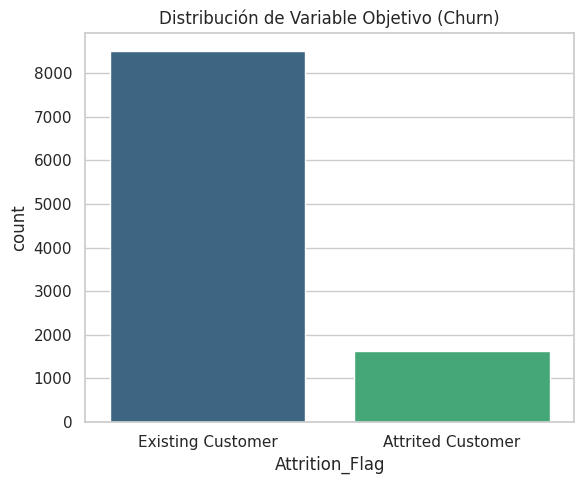

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Attrition_Flag', data=df, palette='viridis')
plt.title('Distribución de Variable Objetivo (Churn)')
plt.tight_layout()
plt.show()

# **Distribución del Monto de Transacciones**

El monto total de transacciones presenta una distribución multimodal, es decir, tiene varios "picos" marcados en lugar de una sola campana central. Se observa un primer grupo grande de clientes con montos entre 1,000 y 3,000, seguido por el pico más alto (la moda) concentrado entre los 4,000 y 5,000. Adicionalmente, aparecen dos aglomeraciones menores y aisladas alrededor de los 8,000 y los 14,000-15,000. Esta forma dentada sugiere fuertemente que existen segmentos o perfiles de gasto muy distintos dentro del banco (por ejemplo: usuarios de bajo consumo, usuarios promedio y un nicho de alto gasto o "premium"). Al realizar el cruce bivariado, será clave verificar si el abandono se concentra en alguno de estos valles o picos específicos.

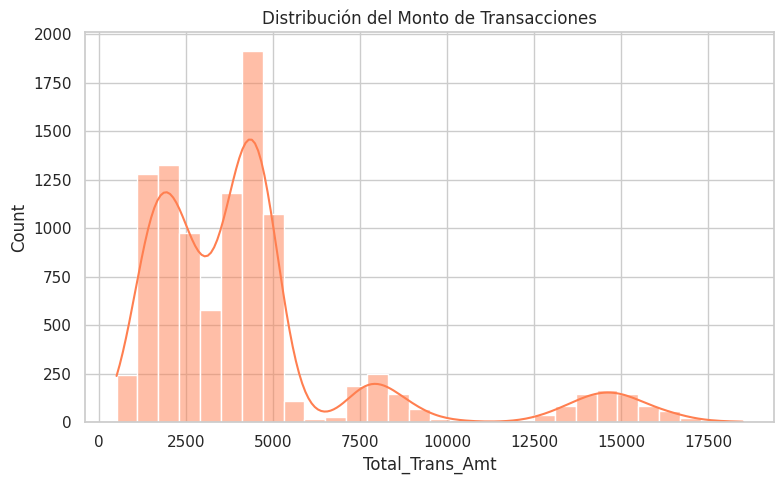

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total_Trans_Amt'], bins=30, kde=True, color='coral')
plt.title('Distribución del Monto de Transacciones')
plt.xlabel('Total_Trans_Amt')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# **Distribución por Categoría de Tarjeta**

El portafolio de tarjetas del banco está masivamente concentrado en la categoría de entrada ("Blue"), superando los 9,000 clientes registrados. Las tarjetas de categorías superiores como "Silver", "Gold" y especialmente "Platinum" representan una porción minúscula del negocio. A nivel analítico, esta variable tiene lo que se conoce como baja varianza. Si durante el modelado notas que las categorías premium no aportan información estadísticamente significativa debido a los pocos registros, una buena estrategia de ingeniería de características (Feature Engineering) sería agrupar "Silver", "Gold" y "Platinum" en una sola macro-categoría llamada "Premium" para reducir ruido y simplificar el análisis

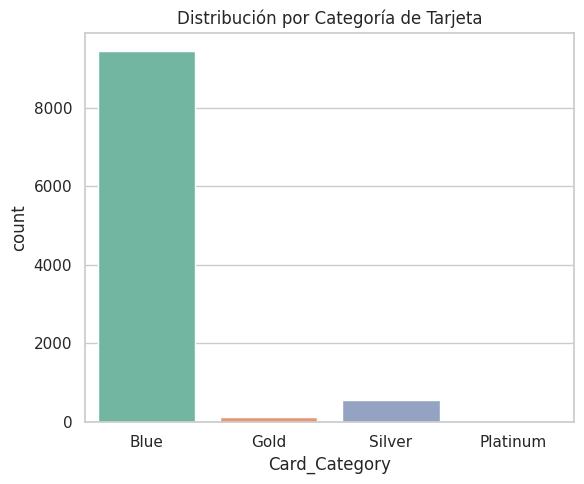

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Card_Category', data=df, palette='Set2')
plt.title('Distribución por Categoría de Tarjeta')
plt.tight_layout()
plt.show()

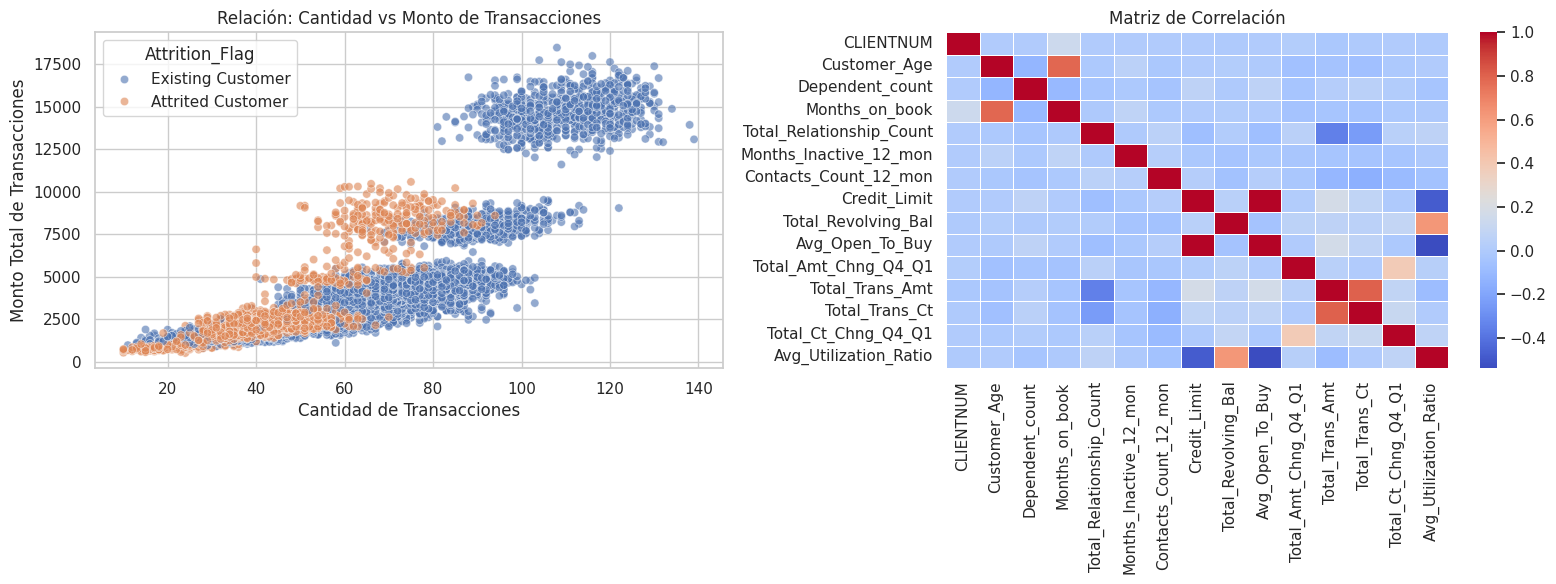

In [ ]:
# Análisis Bivariado (Dispersión y Matriz de Correlación)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Dispersión: Cantidad de transacciones vs Monto total (coloreado por Churn)
sns.scatterplot(x='Total_Trans_Ct', y='Total_Trans_Amt', hue='Attrition_Flag', alpha=0.6, data=df, ax=axes[0])
axes[0].set_title('Relación: Cantidad vs Monto de Transacciones')
axes[0].set_xlabel('Cantidad de Transacciones')
axes[0].set_ylabel('Monto Total de Transacciones')

# Matriz de Correlación (solo numéricas)
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, ax=axes[1])
axes[1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

## Relación: Cantidad de Transacciones vs. Monto Total

**Variables:** `Total_Trans_Ct` vs. `Total_Trans_Amt`


Se observa un patrón visual claro. Los clientes que deciden abandonar (puntos naranjas) se concentran principalmente en un rango de **baja y mediana transaccionalidad**, generalmente entre **40 y 80 transacciones anuales**, y con montos inferiores a **7.500**.

Prácticamente no se observan clientes que abandonaron en los segmentos de **mayor volumen de transacciones**, ubicados hacia la derecha del gráfico.

Esto sugiere que la **disminución en la actividad transaccional del cliente** puede estar relacionada con el abandono. Por lo tanto, la cantidad y el monto de las transacciones pueden ser variables importantes para identificar patrones asociados a la pérdida de clientes.

---

## Matriz de Correlación

La matriz permite identificar posibles **relaciones entre variables** y detectar situaciones de **multicolinealidad** que deben tenerse en cuenta al construir modelos predictivos.

Por ejemplo, se observa una **fuerte correlación positiva** entre:

- `Total_Trans_Amt`: monto total de transacciones.
- `Total_Trans_Ct`: cantidad total de transacciones.

Esta relación resulta coherente, ya que, en términos generales, **a mayor número de compras u operaciones, mayor puede ser el monto acumulado de las transacciones**.

También se observan **correlaciones negativas moderadas** entre algunas variables relacionadas con el límite de crédito y su utilización.

En este sentido, la matriz de correlación permite identificar qué variables aportan información relacionada entre sí y ayuda a tomar decisiones sobre la selección de variables para los modelos predictivos posteriores.

# Análisis Demográfico: Abandono por Género y Nivel Educativo
El problema identifica una tasa de abandono del 16%, lo que equivale aproximadamente a 1.627 clientes. El siguiente código grafica y valida esta proporción.

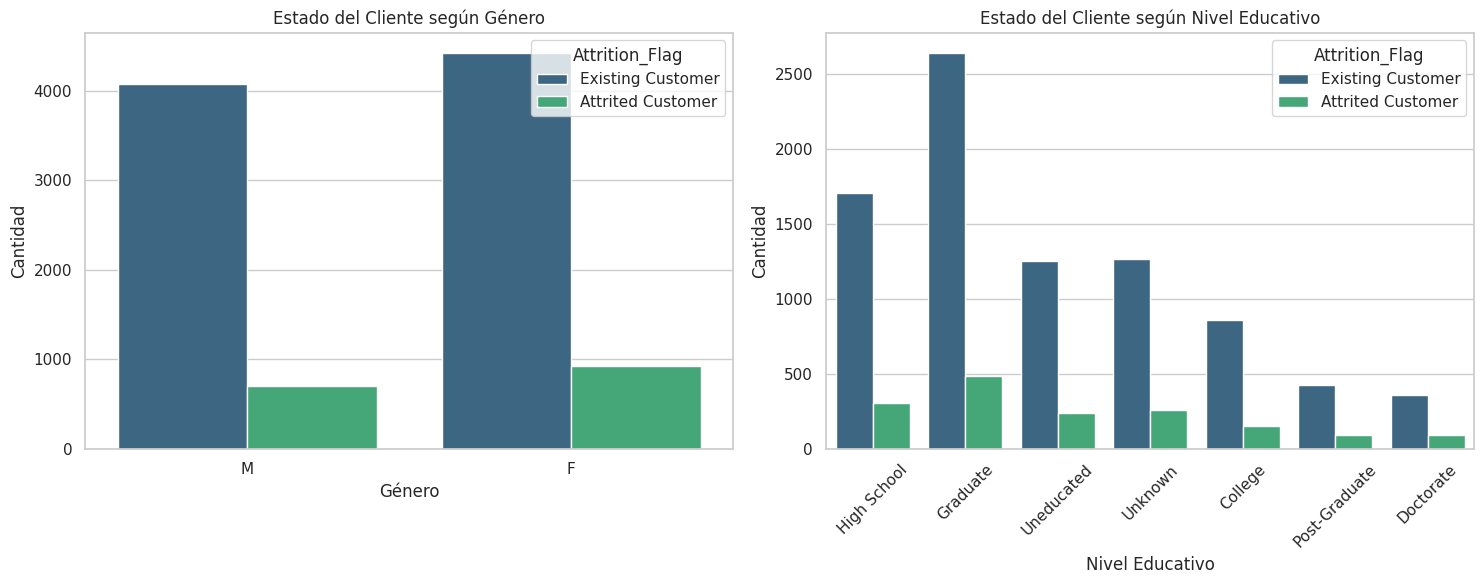

In [ ]:
# Identificar si un segmento poblacional específico tiene una mayor tendencia a cancelar su tarjeta de crédito, lo cual es útil para dirigir estrategias de marketing.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Churn por Género
sns.countplot(data=df, x='Gender', hue='Attrition_Flag', palette='viridis', ax=axes[0])
axes[0].set_title('Estado del Cliente según Género')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('Género')

# Gráfico 2: Churn por Nivel Educativo
sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag', palette='viridis', ax=axes[1])
axes[1].set_title('Estado del Cliente según Nivel Educativo')
axes[1].set_ylabel('Cantidad')
axes[1].set_xlabel('Nivel Educativo')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# **Impacto Financiero: Actividad Transaccional y Límite de Crédito**
La constante pérdida de clientes impacta la actividad financiera. Estas gráficas evalúan el monto de transacciones y el límite de crédito asociado a los clientes perdidos.

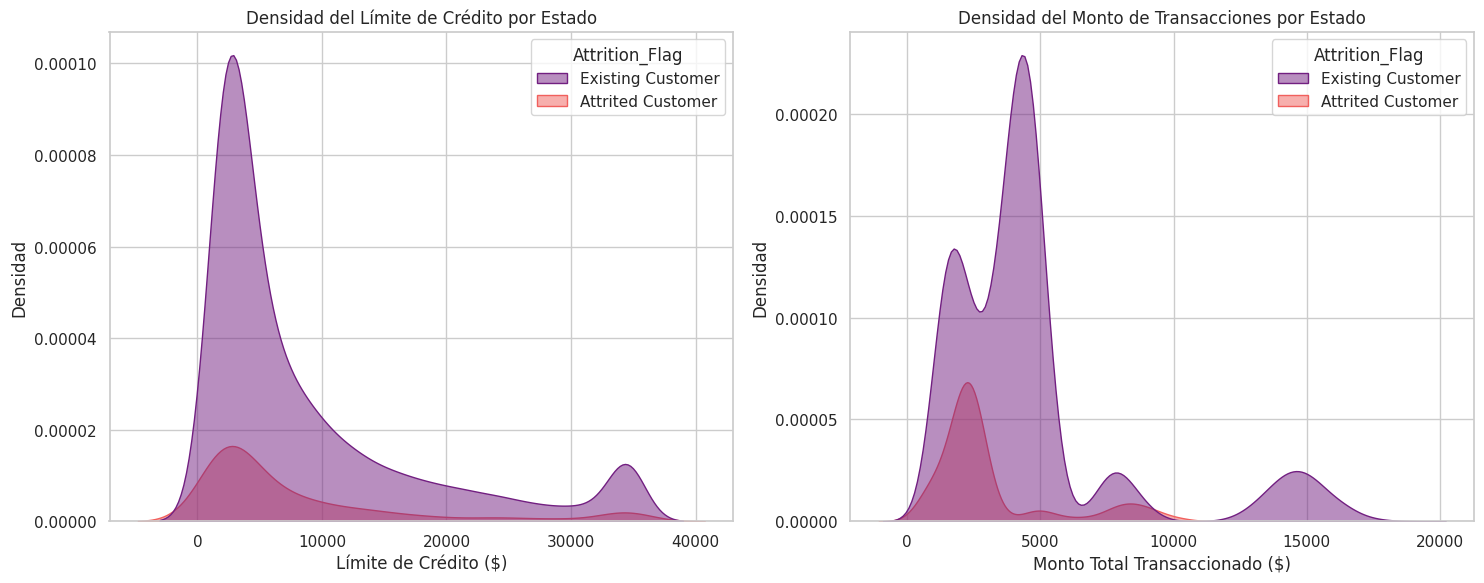

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Densidad del Límite de Crédito
sns.kdeplot(data=df, x='Credit_Limit', hue='Attrition_Flag', fill=True, palette='magma', alpha=0.5, ax=axes[0])
axes[0].set_title('Densidad del Límite de Crédito por Estado')
axes[0].set_ylabel('Densidad')
axes[0].set_xlabel('Límite de Crédito ($)')

# Gráfico 2: Densidad del Monto de Transacciones
sns.kdeplot(data=df, x='Total_Trans_Amt', hue='Attrition_Flag', fill=True, palette='magma', alpha=0.5, ax=axes[1])
axes[1].set_title('Densidad del Monto de Transacciones por Estado')
axes[1].set_ylabel('Densidad')
axes[1].set_xlabel('Monto Total Transaccionado ($)')

plt.tight_layout()
plt.show()

## Preparación del dataset para regresión logística

Para comparar modelos sin mezclar el identificador del cliente con las variables predictoras, se seleccionan variables demográficas y de comportamiento financiero relacionadas con el abandono. `CLIENTNUM` se excluye porque solo identifica registros y no tiene poder predictivo.

Se guardan dos versiones:

- **Dataset sin transformar:** conserva las variables seleccionadas con sus valores originales y `Attrition_Flag` como texto. Sirve como referencia para comparar el efecto de la preparación.
- **Dataset preparado:** convierte el objetivo en una variable binaria (`1` = cliente que abandonó, `0` = cliente existente), aplica *one-hot encoding* a las variables categóricas y estandariza las variables numéricas con media 0 y desviación estándar 1.

El *one-hot encoding* evita imponer un orden numérico falso a categorías nominales u ordinales que no tienen distancias comparables. El escalado es conveniente para la regresión logística porque evita que las variables con valores grandes, como los montos transaccionados, dominen la optimización y permite comparar mejor la magnitud de los coeficientes. La variable objetivo no se escala. El desbalance de clases se debe tratar posteriormente en el modelo, por ejemplo con `class_weight='balanced'`, y no duplicando registros en este dataset base.

La imputación ya se realizó en la sección anterior; por ello, los archivos exportados no contienen nulos en las variables seleccionadas.

In [5]:
# Variables finales seleccionadas para el modelo.
selected_features = [
    'Customer_Age',
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category',
    'Credit_Limit',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]
target = 'Attrition_Flag'
required_columns = selected_features + [target]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise KeyError(f'Faltan columnas requeridas: {missing_columns}')

# Referencia: variables seleccionadas sin transformar.
df_sin_transformar = df[required_columns].copy()
df_sin_transformar.to_csv('BankChurners_variables_seleccionadas_sin_transformar.csv', index=False)

# Objetivo binario: 1 representa abandono y 0 representa cliente existente.
df_modelo = df_sin_transformar.copy()
df_modelo[target] = df_modelo[target].eq('Attrited Customer').astype(int)

categorical_features = [
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
]
numeric_features = [
    'Customer_Age',
    'Credit_Limit',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]

# One-hot encoding y escalado para que todas las predictoras sean numéricas y comparables.
encoded_categoricals = pd.get_dummies(
    df_modelo[categorical_features],
    columns=categorical_features,
    dtype=int
)
scaler = StandardScaler()
scaled_numerics = pd.DataFrame(
    scaler.fit_transform(df_modelo[numeric_features]),
    columns=numeric_features,
    index=df_modelo.index
)
df_logistica = pd.concat(
    [scaled_numerics, encoded_categoricals, df_modelo[[target]]],
    axis=1
)
df_logistica.to_csv('BankChurners_preparado.csv', index=False)

print('Variables seleccionadas:', required_columns)
print('Dataset sin transformar:', df_sin_transformar.shape)
print('Dataset preparado para regresión logística:', df_logistica.shape)
print('Nulos en dataset preparado:', int(df_logistica.isna().sum().sum()))
print('Archivos guardados correctamente.')

Variables seleccionadas: ['Customer_Age', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Attrition_Flag']
Dataset sin transformar: (10127, 11)
Dataset preparado para regresión logística: (10127, 29)
Nulos en dataset preparado: 0
Archivos guardados correctamente.


# Conclusiones

## Valor Generado

El análisis sugiere que el abandono de tarjetas no constituye necesariamente un evento repentino, sino que puede estar precedido por un **proceso gradual de disminución en la actividad del cliente**, reflejado principalmente en la frecuencia de uso y en los montos de transacción.

En particular, se observa una mayor concentración de clientes que abandonaron en rangos de aproximadamente **40 a 80 transacciones anuales** y con menores montos de transacción.

La capacidad de anticipar este comportamiento permite evolucionar de una gestión **reactiva**, en la que se interviene cuando el cliente solicita la cancelación, hacia una gestión **proactiva**, en la que se identifican señales de riesgo y se implementan estrategias de retención antes de que ocurra el abandono.

---

## Recomendaciones y Siguientes Pasos

### 1. Piloto Comercial

Implementar una **prueba piloto A/B** utilizando las predicciones del modelo sobre aproximadamente el **10% de la base actual de clientes**.

Para los clientes identificados como de alto riesgo, se propone evaluar estrategias de retención, como la **exención temporal de la cuota de manejo**, con el objetivo de medir su efectividad sobre la tasa real de retención.

El piloto permitirá comparar los resultados entre un grupo de clientes que recibe la estrategia de retención y un grupo de control, generando evidencia para determinar el impacto real de la intervención.

### 2. Integración de Datos

Para futuras iteraciones del modelo, se recomienda incorporar información relacionada con las **interacciones de los clientes con el servicio de atención**, incluyendo:

- Peticiones, Quejas y Reclamos (PQR).
- Historial de llamadas al servicio al cliente.
- Motivos de contacto.
- Reclamos pendientes o no resueltos.
- Historial de solicitudes relacionadas con el producto.

Estas variables podrían aportar información adicional sobre factores externos asociados al abandono que actualmente no se encuentran representados en el conjunto de datos analizado.